In [1]:
import sys
!{sys.executable} -m pip install lime shap seaborn matplotlib scikit-learn pandas numpy scikit-posthocs xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Directories
PROCESSED_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\data\processed"
OUTPUT_DIR = r"C:\Users\HP\Desktop\thesis_preprocessing\outputs"
FIGURES_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

# Logging Setup
LOG_FILE = os.path.join(OUTPUT_DIR, "Experiment_Statistical_Results.txt")
with open(LOG_FILE, "w", encoding="utf-8") as f:
    f.write("=== THESIS STATISTICAL RESULTS LOG ===\n\n")

def log_result(text):
    print(text)
    with open(LOG_FILE, "a", encoding="utf-8") as f:
        f.write(text + "\n")

# Load the V2 scored and mathematically updated datasets
df_orig = pd.read_csv(os.path.join(PROCESSED_DIR, "01_Original_12k_V2_scored.csv")).dropna(subset=['codebert_score', 'adak_index', 'adak_ss'])
df_dist_a = pd.read_csv(os.path.join(PROCESSED_DIR, "02_Distractor_A_Swapped_12k_V2_scored.csv")).dropna(subset=['codebert_score', 'adak_index', 'adak_ss'])
df_dist_b = pd.read_csv(os.path.join(PROCESSED_DIR, "03_Distractor_B_Shuffled_12k_V2_scored.csv")).dropna(subset=['codebert_score', 'adak_index', 'adak_ss'])

# Labeling: 0=Swapped, 1=Valid, 2=Shuffled
df_orig['label'] = 1
df_dist_a['label'] = 0
df_dist_b['label'] = 2

# Combine
df_combined = pd.concat([df_orig, df_dist_a, df_dist_b], ignore_index=True)

# Ensure word/token count columns exist for the features list
token_col = 'code_token_length' if 'code_token_length' in df_orig.columns else 'token_count'
for df in [df_orig, df_dist_a, df_dist_b, df_combined]:
    if 'comment_word_count' not in df.columns:
        df['comment_word_count'] = df['comment'].apply(lambda x: len(str(x).split()))
    if 'code_token_length' not in df.columns:
        df['code_token_length'] = df[token_col]

# Base Features list
features = ['adak_index', 'codebert_score', 'mcv', 'sfv', 'comment_word_count', 'code_token_length']

log_result("Environment Ready. Datasets loaded with new candidate metrics (adak_ss, lsa_index, adak_sqrt).")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Environment Ready. Datasets loaded with new candidate metrics (adak_ss, lsa_index, adak_sqrt).



1. General Correlation Analysis (Spearman)
Spearman Correlation Matrix against Target Label:
                       label
label               1.000000
comment_word_count  0.001759
code_token_length   0.000000
sfv                 0.000000
adak_lsa           -0.297568
codebert_score     -0.314600
adak_index         -0.376770
adak_damped        -0.388315
adak_ss            -0.396328
adak_sqrt          -0.465785
mcv                -0.521739


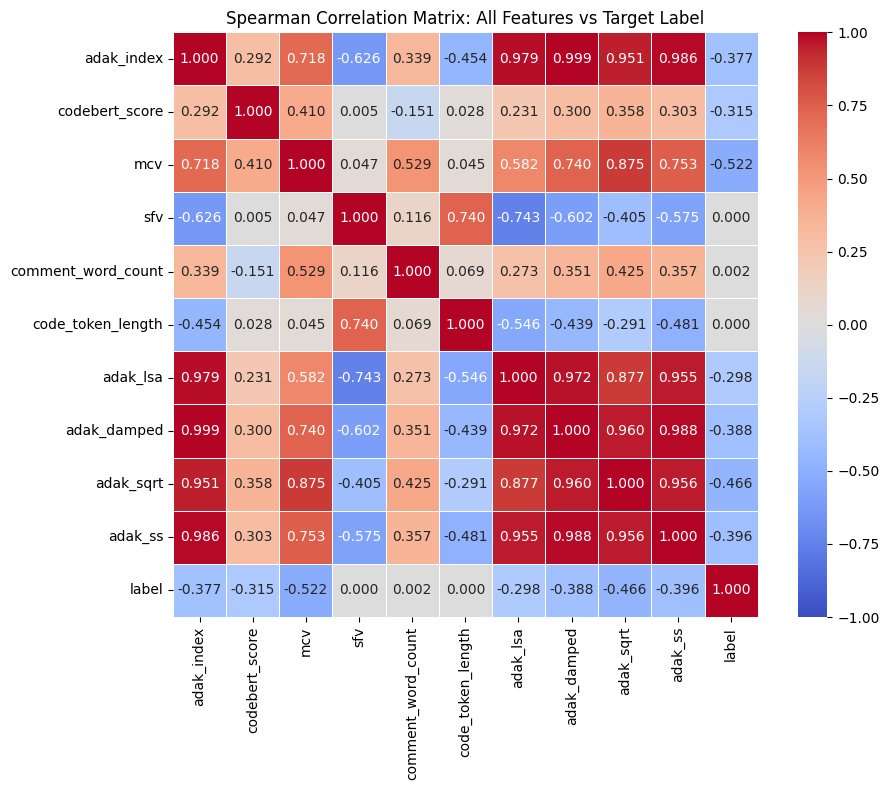

Updated Correlation Heatmap generated and saved.


In [3]:
log_result(f"\n{'='*50}\n1. General Correlation Analysis (Spearman)\n{'='*50}")

# Calculate Spearman correlation matrix including standard features, new candidate metrics, and the target label
# FIXED: Changed 'lsa_index' to 'adak_lsa' and added 'adak_damped'
corr_cols = features + ['adak_lsa', 'adak_damped', 'adak_sqrt', 'adak_ss', 'label']
corr_matrix = df_combined[corr_cols].corr(method='spearman')

# Log the correlation results to the log file
log_result("Spearman Correlation Matrix against Target Label:")
log_result(corr_matrix[['label']].sort_values(by='label', ascending=False).to_string())

# Plot the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='coolwarm', vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
plt.title('Spearman Correlation Matrix: All Features vs Target Label')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp1_Correlation_Heatmap.png"), dpi=300, bbox_inches='tight')
plt.show()

log_result("Updated Correlation Heatmap generated and saved.")

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from xgboost import XGBClassifier

log_result(f"\n{'='*50}\n2. Model Comparison Arena & 4x3 Ablation Grid\n{'='*50}")

# Define the targets and target names
X = df_combined[features]
y = df_combined['label']
target_names = ['Swapped (0)', 'Valid (1)', 'Shuffled (2)']

# Perform a stratified 80/20 train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Define our 3 distinct Feature Sets for the Ablation Study
feature_sets = {
    "Full Set (6 Features)": ['adak_index', 'codebert_score', 'mcv', 'sfv', 'comment_word_count', 'code_token_length'],
    "Structural-Only (5 Features)": ['adak_index', 'mcv', 'sfv', 'comment_word_count', 'code_token_length'],
    "Volume-Ablated Semantic (1 Feature)": ['codebert_score']
}

# Define our 4 baseline Classifiers (including XGBoost)
classifiers = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "XGBoost Classifier": XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')
}

# Accumulate results to print a clean summary table at the end
ablation_results = []

# Run the 4x3 Grid Search
for fs_name, fs_cols in feature_sets.items():
    log_result(f"\n--- Feature Set: {fs_name} ---")
    
    # Scale features dynamically based on the current subset
    scaler = StandardScaler()
    X_train_scaled_sub = pd.DataFrame(scaler.fit_transform(X_train[fs_cols]), columns=fs_cols)
    X_test_scaled_sub = pd.DataFrame(scaler.transform(X_test[fs_cols]), columns=fs_cols)
    
    for clf_name, clf in classifiers.items():
        log_result(f"Training {clf_name}...")
        clf.fit(X_train_scaled_sub, y_train)
        y_pred = clf.predict(X_test_scaled_sub)
        
        acc = accuracy_score(y_test, y_pred)
        
        # Extract classification report as a dictionary to get the "Swapped" F1-Score
        report = classification_report(y_test, y_pred, target_names=target_names, output_dict=True)
        swapped_f1 = report['Swapped (0)']['f1-score']
        
        ablation_results.append({
            "Feature Set": fs_name,
            "Classifier": clf_name,
            "Global Accuracy": round(acc, 4),
            "Swapped F1-Score": round(swapped_f1, 4)
        })

# Format and log the final 4x3 comparison grid
summary_df = pd.DataFrame(ablation_results)
log_result(f"\n{'='*50}\nFINAL 4x3 ABLATION GRID SUMMARY\n{'='*50}")
log_result(summary_df.to_string(index=False))

# Identify and log the winning configuration
best_row = summary_df.loc[summary_df['Global Accuracy'].idxmax()]
log_result(f"\nWINNING CONFIGURATION: {best_row['Classifier']} on {best_row['Feature Set']} with Accuracy = {best_row['Global Accuracy']}")


2. Model Comparison Arena & 4x3 Ablation Grid

--- Feature Set: Full Set (6 Features) ---
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost Classifier...

--- Feature Set: Structural-Only (5 Features) ---
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost Classifier...

--- Feature Set: Volume-Ablated Semantic (1 Feature) ---
Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training XGBoost Classifier...

FINAL 4x3 ABLATION GRID SUMMARY
                        Feature Set          Classifier  Global Accuracy  Swapped F1-Score
              Full Set (6 Features) Logistic Regression           0.8671            0.8060
              Full Set (6 Features)       Decision Tree           0.8874            0.8703
              Full Set (6 Features)       Random Forest           0.8919            0.8786
              Full Set (6 Features)  XGBoost Classifier   


3. Interpretability Analysis (SHAP & LIME) for XGBoost Classifier
Retraining winning model on Full Feature Set for SHAP/LIME...
Calculating SHAP values...


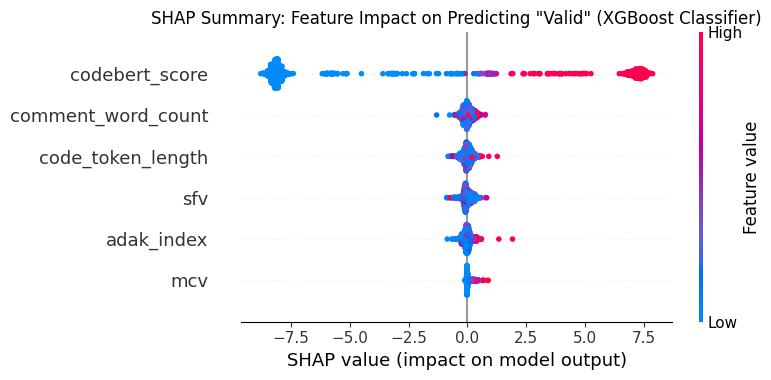

SHAP summary plot generated successfully.

Calculating LIME (Local Interpretability)...
LIME local predictions saved as HTML files in figures directory.


In [7]:
import shap
import lime
import lime.lime_tabular
from xgboost import XGBClassifier
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# 1. Re-scale the FULL 6-feature set for the interpretability analysis
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[features]), columns=features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[features]), columns=features)

# 2. Explicitly set the winning model from the ablation grid
best_model_name = "XGBoost Classifier"
best_model = XGBClassifier(n_estimators=100, random_state=42, n_jobs=-1, eval_metric='logloss')

log_result(f"\n{'='*50}\n3. Interpretability Analysis (SHAP & LIME) for {best_model_name}\n{'='*50}")

# Retrain the winning model on the FULL 6-feature set for interpretability
log_result("Retraining winning model on Full Feature Set for SHAP/LIME...")
best_model.fit(X_train_scaled, y_train)

# ---------------------------------------------
# 1. SHAP (Global Explanation)
# ---------------------------------------------
log_result("Calculating SHAP values...")
X_test_sample = X_test_scaled.sample(1000, random_state=42)

# Select the right SHAP explainer based on the winning model type
if "Forest" in best_model_name or "Tree" in best_model_name or "XGBoost" in best_model_name:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_sample)
else:
    explainer = shap.LinearExplainer(best_model, X_train_scaled)
    shap_values = explainer.shap_values(X_test_sample)

# Handle multi-class shape variations
if isinstance(shap_values, list):
    shap_to_plot = shap_values[1] # Predicts Class 1 (Valid)
else:
    if len(np.shape(shap_values)) == 2:
        shap_to_plot = shap_values
    else:
        shap_to_plot = shap_values[:, :, 1]

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_to_plot, X_test_sample, show=False)
plt.title(f'SHAP Summary: Feature Impact on Predicting "Valid" ({best_model_name})')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp1_SHAP_Summary_BestModel.png"), dpi=300, bbox_inches='tight')
plt.show()
log_result("SHAP summary plot generated successfully.")

# ---------------------------------------------
# 2. LIME (Local Explanation)
# ---------------------------------------------
log_result("\nCalculating LIME (Local Interpretability)...")

# Initialize LIME Explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled.values,
    feature_names=features,
    class_names=target_names,
    mode='classification'
)

# Pick two specific rows from the test set to explain
valid_idx = y_test[y_test == 1].index[0]
swapped_idx = y_test[y_test == 0].index[0]

pos_valid = np.where(X_test.index == valid_idx)[0][0]
pos_swapped = np.where(X_test.index == swapped_idx)[0][0]

# Explain the Valid instance
exp_valid = lime_explainer.explain_instance(X_test_scaled.values[pos_valid], best_model.predict_proba, num_features=4)
exp_valid.save_to_file(os.path.join(FIGURES_DIR, 'LIME_Explanation_Valid_Sample.html'))

# Explain the Swapped instance
exp_swapped = lime_explainer.explain_instance(X_test_scaled.values[pos_swapped], best_model.predict_proba, num_features=4)
exp_swapped.save_to_file(os.path.join(FIGURES_DIR, 'LIME_Explanation_Swapped_Sample.html'))

log_result("LIME local predictions saved as HTML files in figures directory.")


Experiment 3: Complexity Threshold & Trajectory Analysis
Spearman Correlation Trajectories across Complexity Buckets:

--- Metric: Original Adak ---
Bucket: Small (SFV < 15)     | n=6002  | Spearman r_s: 0.4568 (p=2.4602e-307)
Bucket: Medium (SFV 15-40)   | n=4387  | Spearman r_s: 0.4138 (p=4.6937e-181)
Bucket: Large (SFV > 40)     | n=1611  | Spearman r_s: 0.4499 (p=4.1503e-81)

--- Metric: Log-Stabilized (LSA) ---
Bucket: Small (SFV < 15)     | n=6002  | Spearman r_s: 0.4239 (p=2.0624e-260)
Bucket: Medium (SFV 15-40)   | n=4387  | Spearman r_s: 0.3920 (p=4.3967e-161)
Bucket: Large (SFV > 40)     | n=1611  | Spearman r_s: 0.4297 (p=2.1644e-73)

--- Metric: Linear Damped ---
Bucket: Small (SFV < 15)     | n=6002  | Spearman r_s: 0.4648 (p=0.0000e+00)
Bucket: Medium (SFV 15-40)   | n=4387  | Spearman r_s: 0.4146 (p=7.8349e-182)
Bucket: Large (SFV > 40)     | n=1611  | Spearman r_s: 0.4501 (p=3.5083e-81)

--- Metric: Square-Root Damped ---
Bucket: Small (SFV < 15)     | n=6002  | Spearm

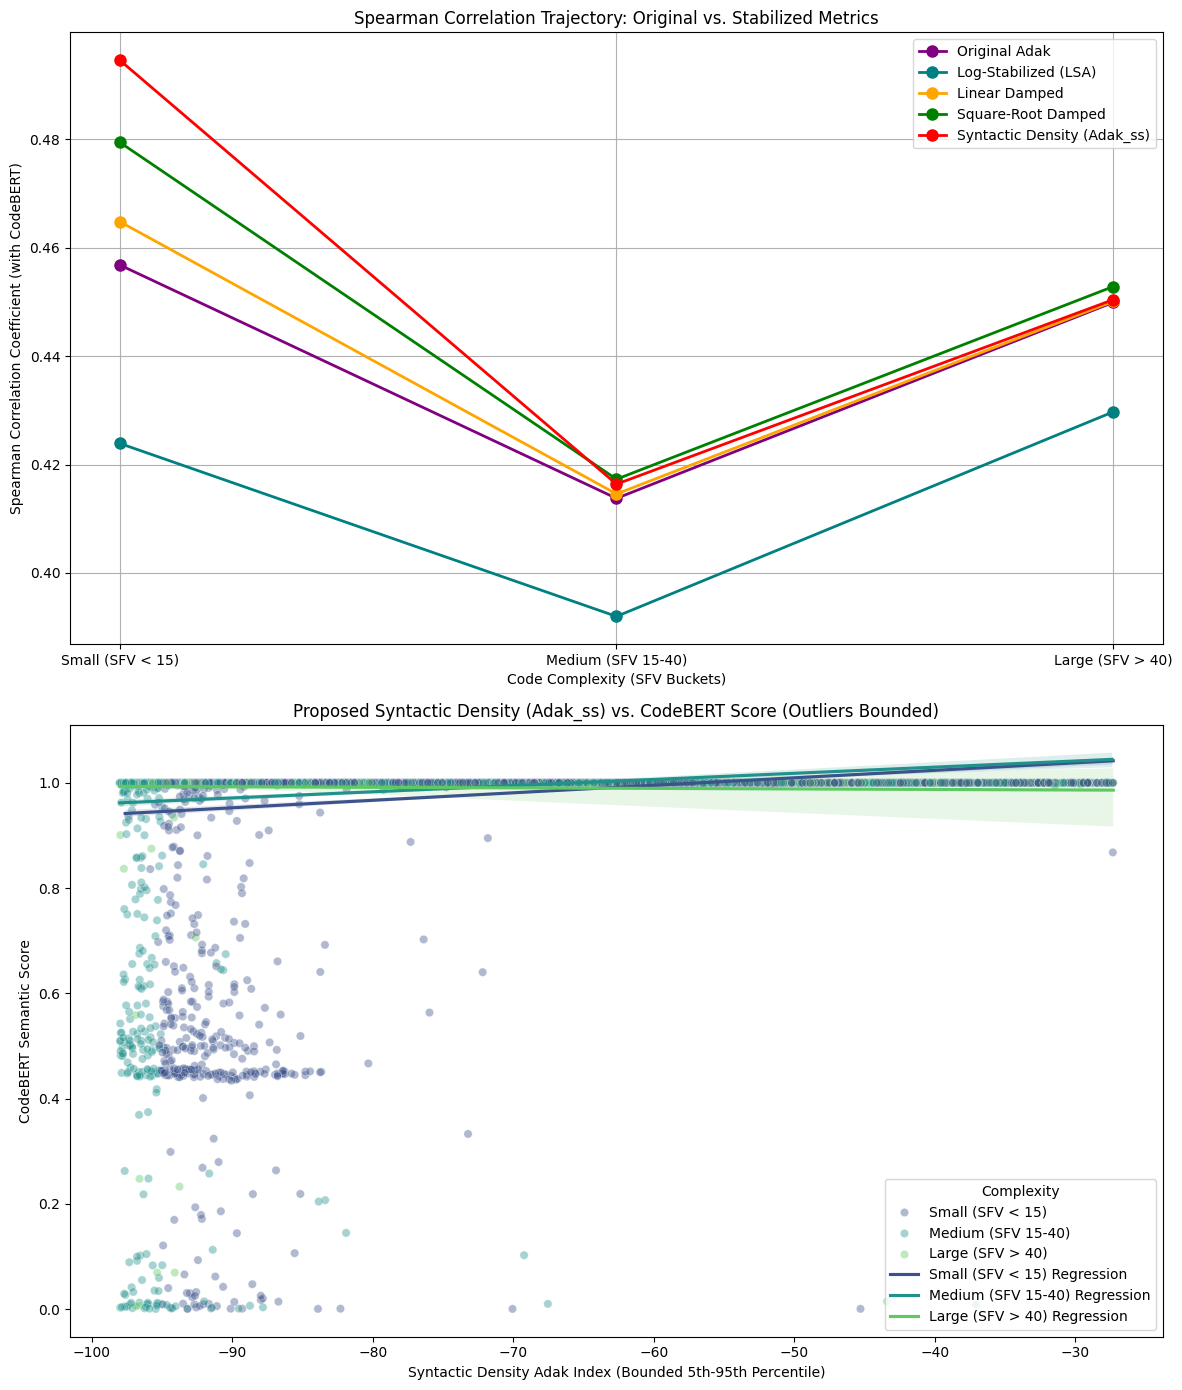


Complexity trajectory analysis successfully completed. Stabilized charts saved.


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

log_result(f"\n{'='*50}\nExperiment 3: Complexity Threshold & Trajectory Analysis\n{'='*50}")

# Segment the original dataset into the three complexity buckets
bins = [0, 15, 40, np.inf]
labels = ['Small (SFV < 15)', 'Medium (SFV 15-40)', 'Large (SFV > 40)']
df_orig['complexity_bucket'] = pd.cut(df_orig['sfv'], bins=bins, labels=labels)

# We will evaluate all five metric variants
metrics_to_evaluate = {
    "Original Adak": "adak_index",
    "Log-Stabilized (LSA)": "adak_lsa",
    "Linear Damped": "adak_damped",
    "Square-Root Damped": "adak_sqrt",
    "Syntactic Density (Adak_ss)": "adak_ss"
}

trajectory_results = []

log_result("Spearman Correlation Trajectories across Complexity Buckets:")

# Calculate correlations for each metric in each bucket
for metric_name, col_name in metrics_to_evaluate.items():
    log_result(f"\n--- Metric: {metric_name} ---")
    for bucket in labels:
        subset = df_orig[df_orig['complexity_bucket'] == bucket]
        if len(subset) > 1:
            corr, p_val = stats.spearmanr(subset[col_name], subset['codebert_score'])
            log_result(f"Bucket: {bucket:<20} | n={len(subset):<5} | Spearman r_s: {corr:.4f} (p={p_val:.4e})")
            trajectory_results.append({
                "Metric": metric_name,
                "Complexity Bucket": bucket,
                "Spearman Correlation": corr
            })

# Format into a clean summary DataFrame for logging
traj_df = pd.DataFrame(trajectory_results)
pivot_df = traj_df.pivot(index='Metric', columns='Complexity Bucket', values='Spearman Correlation')
pivot_df = pivot_df[labels] # Ensure column ordering matches complexity scale

log_result(f"\n{'='*50}\nFINAL SPEARMAN CORRELATION TRAJECTORY COMPARISON\n{'='*50}")
log_result(pivot_df.round(4).to_string())

# ---------------------------------------------
# PLOTTING THE COMPARISON CHARTS (Figure 18)
# ---------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# Plot 1: The Comparative Spearman Trajectories
colors = ['purple', 'teal', 'orange', 'green', 'red']
for idx, (metric_name, col_name) in enumerate(metrics_to_evaluate.items()):
    metric_data = traj_df[traj_df['Metric'] == metric_name]
    axes[0].plot(metric_data['Complexity Bucket'], metric_data['Spearman Correlation'], 
                marker='o', label=metric_name, color=colors[idx], linewidth=2, markersize=8)

axes[0].set_title('Spearman Correlation Trajectory: Original vs. Stabilized Metrics')
axes[0].set_xlabel('Code Complexity (SFV Buckets)')
axes[0].set_ylabel('Spearman Correlation Coefficient (with CodeBERT)')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Scatter plot of Adak_ss vs CodeBERT using the proposed Syntactic Density metric
adak_lower, adak_upper = df_orig['adak_ss'].quantile([0.05, 0.95])
filtered_df = df_orig[(df_orig['adak_ss'] >= adak_lower) & (df_orig['adak_ss'] <= adak_upper)]

sns.scatterplot(data=filtered_df, x='adak_ss', y='codebert_score', hue='complexity_bucket', 
                palette='viridis', alpha=0.4, ax=axes[1])

reg_colors = sns.color_palette('viridis', 3)
for idx, bucket in enumerate(labels):
    bucket_data = filtered_df[filtered_df['complexity_bucket'] == bucket]
    if len(bucket_data) > 1:
        sns.regplot(data=bucket_data, x='adak_ss', y='codebert_score', 
                    scatter=False, ax=axes[1], line_kws={'color': reg_colors[idx]}, label=f'{bucket} Regression')

axes[1].set_title('Proposed Syntactic Density (Adak_ss) vs. CodeBERT Score (Outliers Bounded)')
axes[1].set_xlabel('Syntactic Density Adak Index (Bounded 5th-95th Percentile)')
axes[1].set_ylabel('CodeBERT Semantic Score')
axes[1].legend(title='Complexity', loc='lower right')

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, "Exp3_Complexity_Threshold_All_Stabilized.png"), dpi=300, bbox_inches='tight')
plt.show()

log_result("\nComplexity trajectory analysis successfully completed. Stabilized charts saved.")



In [9]:
import scikit_posthocs as sp 

log_result(f"\n{'='*50}\nExperiment 2: Paradigm Bias Analysis (Adak_ss)\n{'='*50}")

# Updated Paradigm Map
paradigm_map = {
    'java': 'Object-Oriented (Statically Typed)',
    'ruby': 'Object-Oriented (Dynamically Typed)',
    'go': 'Procedural (Statically Typed)',
    'python': 'Multi-Paradigm (Dynamically Typed)',
    'javascript': 'Multi-Paradigm (Dynamically Typed)',
    'php': 'Multi-Paradigm (Dynamically Typed)'
}
df_orig['paradigm'] = df_orig['language'].str.lower().map(paradigm_map)

# 1. Kruskal-Wallis Test across paradigms on Adak_ss
paradigms = df_orig['paradigm'].dropna().unique()
adak_groups = [df_orig[df_orig['paradigm'] == p]['adak_ss'].dropna() for p in paradigms]

h_stat, p_value = stats.kruskal(*adak_groups)
log_result(f"Kruskal-Wallis Results on Adak_ss:\nH-Statistic: {h_stat:.4f} | p-value: {p_value:.4e}\n")

if p_value < 0.05:
    log_result("Conclusion: Significant variance still exists between paradigms.")
    dunn_results = sp.posthoc_dunn(df_orig, val_col='adak_ss', group_col='paradigm', p_adjust='bonferroni')
    log_result("Dunn's Post-Hoc Test:\n" + str(dunn_results))
else:
    log_result("Conclusion: Paradigm Bias ELIMINATED! Adak_ss is paradigm neutral.")

# 2. INDIVIDUAL WHISKER PLOTS (Per Language for Adak_ss)
for lang in df_orig['language'].unique():
    lang_data = df_orig[df_orig['language'] == lang]
    
    plt.figure(figsize=(6, 4))
    sns.boxplot(y=lang_data['adak_ss'], color='mediumseagreen')
    plt.yscale('symlog') 
    plt.title(f'Syntactic Density Adak_ss Distribution: {lang.upper()}')
    plt.ylabel('Adak_ss Index')
    plt.savefig(os.path.join(FIGURES_DIR, f"Exp2_AdakSS_Whisker_{lang.upper()}.png"), dpi=300, bbox_inches='tight')
    plt.close() # Close to prevent rendering all 6 in the notebook output
    
log_result("Adak_ss Boxplots generated and saved to figures folder.")


Experiment 2: Paradigm Bias Analysis (Adak_ss)
Kruskal-Wallis Results on Adak_ss:
H-Statistic: 704.0487 | p-value: 2.7805e-152

Conclusion: Significant variance still exists between paradigms.
Dunn's Post-Hoc Test:
                                     Multi-Paradigm (Dynamically Typed)  \
Multi-Paradigm (Dynamically Typed)                         1.000000e+00   
Object-Oriented (Dynamically Typed)                        1.222508e-09   
Object-Oriented (Statically Typed)                         1.000000e+00   
Procedural (Statically Typed)                             7.460866e-117   

                                     Object-Oriented (Dynamically Typed)  \
Multi-Paradigm (Dynamically Typed)                          1.222508e-09   
Object-Oriented (Dynamically Typed)                         1.000000e+00   
Object-Oriented (Statically Typed)                          7.253389e-06   
Procedural (Statically Typed)                              1.085688e-126   

                           